In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [30]:
# Set random seed for reproducibility
tf.random.set_seed(42)

In [31]:
# Load the input and target data
X = pd.read_excel('data1319.xlsx', sheet_name=0, usecols='D:S', skiprows=1, nrows=765).values
y = pd.read_excel('data1319.xlsx', sheet_name=0, usecols='T', skiprows=1, nrows=765).values

In [32]:
# Expand dimensions of target data if necessary
t = np.expand_dims(y, axis=1) if y.ndim == 1 else y

In [33]:
# Normalize input and target data
input_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [34]:
x_scaled = input_scaler.fit_transform(X)
t_scaled = target_scaler.fit_transform(t)

In [35]:
# Split data into training, validation, and testing sets
x_train, x_temp, t_train, t_temp = train_test_split(x_scaled, t_scaled, test_size=0.3, random_state=42)
x_val, x_test, t_val, t_test = train_test_split(x_temp, t_temp, test_size=0.5, random_state=42)

In [36]:
# Create a fitting network
hidden_layer_size = 10
model = Sequential([
    Dense(hidden_layer_size, activation='relu', input_shape=(x_scaled.shape[1],)),
    Dense(t_scaled.shape[1], activation='relu')
])

In [37]:
# Display the model summary
print("Model Summary:")
model.summary()

Model Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 10)                170       
                                                                 
 dense_3 (Dense)             (None, 1)                 11        
                                                                 
Total params: 181 (724.00 Byte)
Trainable params: 181 (724.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [38]:
# Compile the model
model.compile(optimizer=Adam(), loss=MeanSquaredError(), metrics=['mae'])

In [39]:
# Train the network
history = model.fit(x_train, t_train, epochs=100, batch_size=10,
                    validation_data=(x_val, t_val), verbose=1)

Epoch 1/100
54/54 [==============================] - 1s 8ms/step - loss: 0.9853 - mae: 0.8166 - val_loss: 1.0837 - val_mae: 0.8702
Epoch 2/100
54/54 [==============================] - 0s 5ms/step - loss: 1.0925 - mae: 0.8511 - val_loss: 1.1709 - val_mae: 0.8999
Epoch 3/100
54/54 [==============================] - 0s 5ms/step - loss: 0.9954 - mae: 0.7854 - val_loss: 0.8616 - val_mae: 0.7298
Epoch 4/100
54/54 [==============================] - 0s 5ms/step - loss: 0.7772 - mae: 0.6623 - val_loss: 0.8022 - val_mae: 0.6944
Epoch 5/100
54/54 [==============================] - 0s 5ms/step - loss: 0.7525 - mae: 0.6438 - val_loss: 0.7628 - val_mae: 0.6695
Epoch 6/100
54/54 [==============================] - 0s 5ms/step - loss: 0.7352 - mae: 0.6315 - val_loss: 0.7988 - val_mae: 0.6853
Epoch 7/100
54/54 [==============================] - 0s 5ms/step - loss: 0.7397 - mae: 0.6286 - val_loss: 0.7527 - val_mae: 0.6563
Epoch 8/100
54/54 [==============================] - 0s 5ms/step - loss: 0.7228 - m

In [40]:
# Test the network
y_pred = model.predict(x_test)
performance = model.evaluate(x_test, t_test, verbose=0)

4/4 [==============================] - 0s 4ms/step


In [41]:
# Save the trained model
model_save_path = "mktRegMdl.keras"
model.save(model_save_path)
print(f"Model saved at: {model_save_path}")

Model saved at: mktRegMdl.keras


In [42]:
# Calculate training and testing adjusted accuracies
train_mse = model.evaluate(x_train, t_train, verbose=0)[0]
test_mse = performance[0]
target_variance = np.var(t_scaled)

In [43]:
train_accuracy = max(0, 1 - (train_mse / target_variance))
test_accuracy = max(0, 1 - (test_mse / target_variance))

In [44]:
# Calculate R-squared for training and testing
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

4/4 [==============================] - 0s 2ms/step


In [45]:
train_r2 = r2_score(t_train, train_pred)
test_r2 = r2_score(t_test, test_pred)

In [46]:
# Print performance results
print("\nPerformance Results:")
print("Test Performance (MSE):", test_mse)
print("Adjusted Training Accuracy:", train_accuracy)
print("Adjusted Testing Accuracy:", test_accuracy)
print("Training R-squared:", train_r2)
print("Testing R-squared:", test_r2)


Performance Results:
Test Performance (MSE): 0.030348453670740128
Adjusted Training Accuracy: 0.5428198726771956
Adjusted Testing Accuracy: 0.40825692011191417
Training R-squared: 0.815679935484886
Testing R-squared: 0.7638324668850404


In [47]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(t_test, y_pred)
mae

0.08361298591660982

In [48]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(t_test, y_pred)
mse

0.013345658835047326

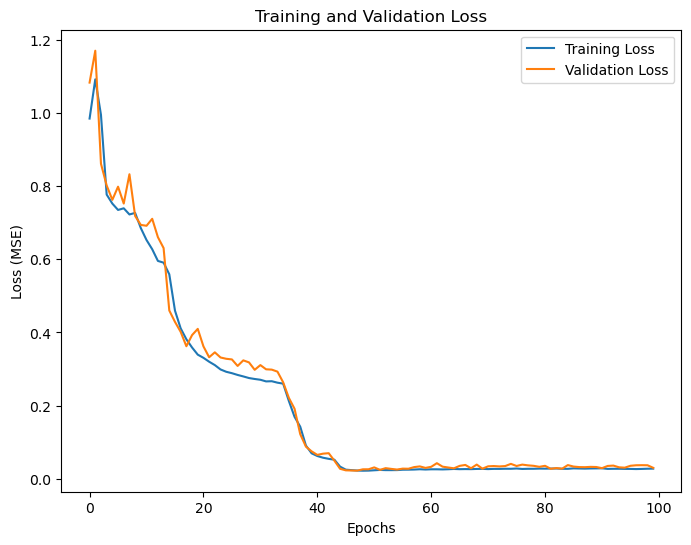

In [49]:
# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.show()

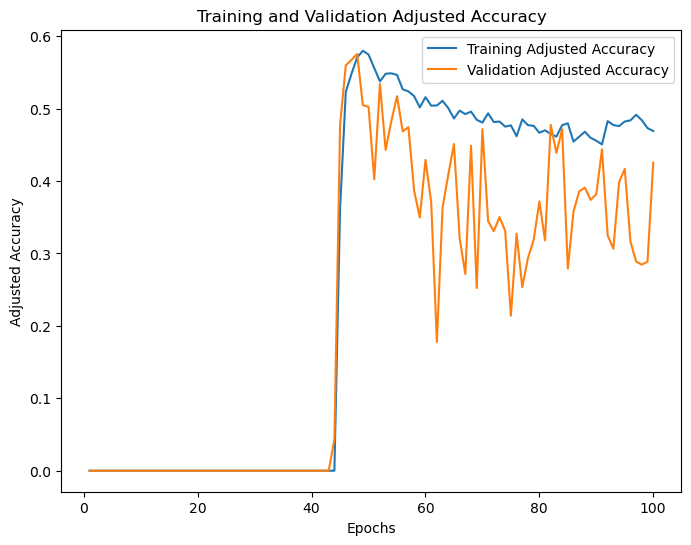

In [50]:
# Plot adjusted accuracy results
epochs = range(1, len(history.history['loss']) + 1)
train_accuracy_epoch = [max(0, 1 - (loss / target_variance)) for loss in history.history['loss']]
val_accuracy_epoch = [max(0, 1 - (loss / target_variance)) for loss in history.history['val_loss']]
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_accuracy_epoch, label='Training Adjusted Accuracy')
plt.plot(epochs, val_accuracy_epoch, label='Validation Adjusted Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Adjusted Accuracy')
plt.title('Training and Validation Adjusted Accuracy')
plt.show()

In [51]:
# Optional: Generate a simple function for deployment
def my_neural_network_function(new_x):
    new_x_scaled = input_scaler.transform(new_x)
    y_scaled = model.predict(new_x_scaled)
    return target_scaler.inverse_transform(y_scaled)